**Image:** `emma.jpg`

**Sub questions:**
- **(a)** Apply **Gaussian smoothing**
- **(b)** Apply **median filtering**

In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../outputs/q8', exist_ok=True)

# Load and resize jeniffer.jpg — original is 3840x2160 (too large)
# Resize to 960x540 for efficient processing while preserving quality
img_orig = cv.imread('../images/a1images/emma.jpg', cv.IMREAD_GRAYSCALE)
assert img_orig is not None, "Could not load emma.jpg"

img = cv.resize(img_orig, (960, 540), interpolation=cv.INTER_AREA)

print(f"Original size : {img_orig.shape}")
print(f"Working size  : {img.shape}")
print(f"Dtype         : {img.dtype}")
print(f"Mean          : {img.mean():.2f} | Std: {img.std():.2f}")


Original size : (810, 720)
Working size  : (540, 960)
Dtype         : uint8
Mean          : 92.25 | Std: 55.90


## Add Salt and Pepper Noise

In [18]:
def add_salt_pepper_noise(image, noise_density=0.05):
    """
    Add salt and pepper noise to a grayscale image.

    Parameters:
        image         : uint8 grayscale image
        noise_density : fraction of pixels to corrupt (e.g. 0.05 = 5%)
                        Half will be salt (255), half will be pepper (0)

    Returns:
        noisy : corrupted uint8 image
        mask  : bool array — True where noise was added
    """
    noisy = image.copy()
    H, W  = image.shape
    n_pixels = int(H * W * noise_density)

    # Salt — set random pixels to 255
    salt_coords = (np.random.randint(0, H, n_pixels // 2),
                   np.random.randint(0, W, n_pixels // 2))
    noisy[salt_coords] = 255

    # Pepper — set random pixels to 0
    pepper_coords = (np.random.randint(0, H, n_pixels // 2),
                     np.random.randint(0, W, n_pixels // 2))
    noisy[pepper_coords] = 0

    return noisy


np.random.seed(42)   # reproducible noise
img_noisy = add_salt_pepper_noise(img, noise_density=0.05)

# Count actual noise pixels added
salt_count   = np.sum(img_noisy == 255) - np.sum(img == 255)
pepper_count = np.sum(img_noisy == 0)   - np.sum(img == 0)
total        = img.size
print(f"Noise density : 5%  (salt={salt_count:,}, pepper={pepper_count:,})")
print(f"Noisy image   — Mean: {img_noisy.mean():.2f} | Std: {img_noisy.std():.2f}")


Noise density : 5%  (salt=12,471, pepper=12,166)
Noisy image   — Mean: 93.92 | Std: 61.77


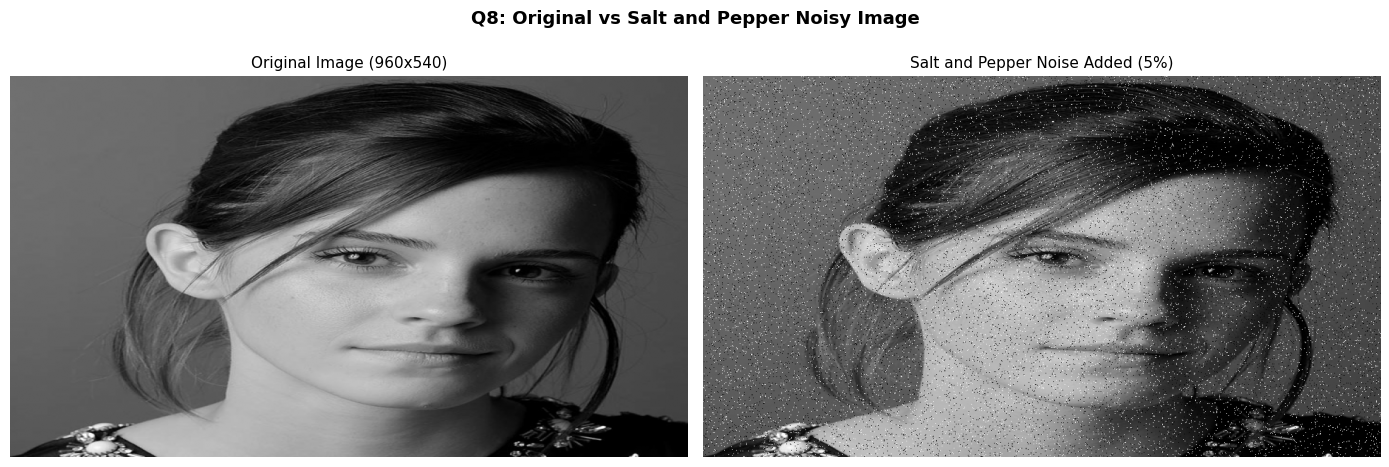

In [19]:
# Show original vs noisy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q8: Original vs Salt and Pepper Noisy Image', fontsize=13, fontweight='bold')

axes[0].imshow(img,       cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image (960x540)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(img_noisy, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Salt and Pepper Noise Added (5%)', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q8/q8_original_noisy.png', dpi=150, bbox_inches='tight')
plt.show()


## (a) Gaussian Smoothing

In [20]:
# Apply Gaussian smoothing with different kernel sizes
gauss_3  = cv.GaussianBlur(img_noisy, (3, 3), sigmaX=1)
gauss_5  = cv.GaussianBlur(img_noisy, (5, 5), sigmaX=2)
gauss_7  = cv.GaussianBlur(img_noisy, (7, 7), sigmaX=2)

print("Gaussian filtering results (vs noisy):")
for name, filtered in [('Gauss 3x3', gauss_3), ('Gauss 5x5', gauss_5), ('Gauss 7x7', gauss_7)]:
    remaining_sp = np.sum(filtered == 0) + np.sum(filtered == 255)
    print(f"  {name} — Mean: {filtered.mean():.2f} | Std: {filtered.std():.2f} "
          f"| Remaining extreme pixels: {remaining_sp:,}")


Gaussian filtering results (vs noisy):
  Gauss 3x3 — Mean: 93.92 | Std: 53.93 | Remaining extreme pixels: 7,588
  Gauss 5x5 — Mean: 93.92 | Std: 52.88 | Remaining extreme pixels: 4,381
  Gauss 7x7 — Mean: 93.92 | Std: 52.56 | Remaining extreme pixels: 2,232


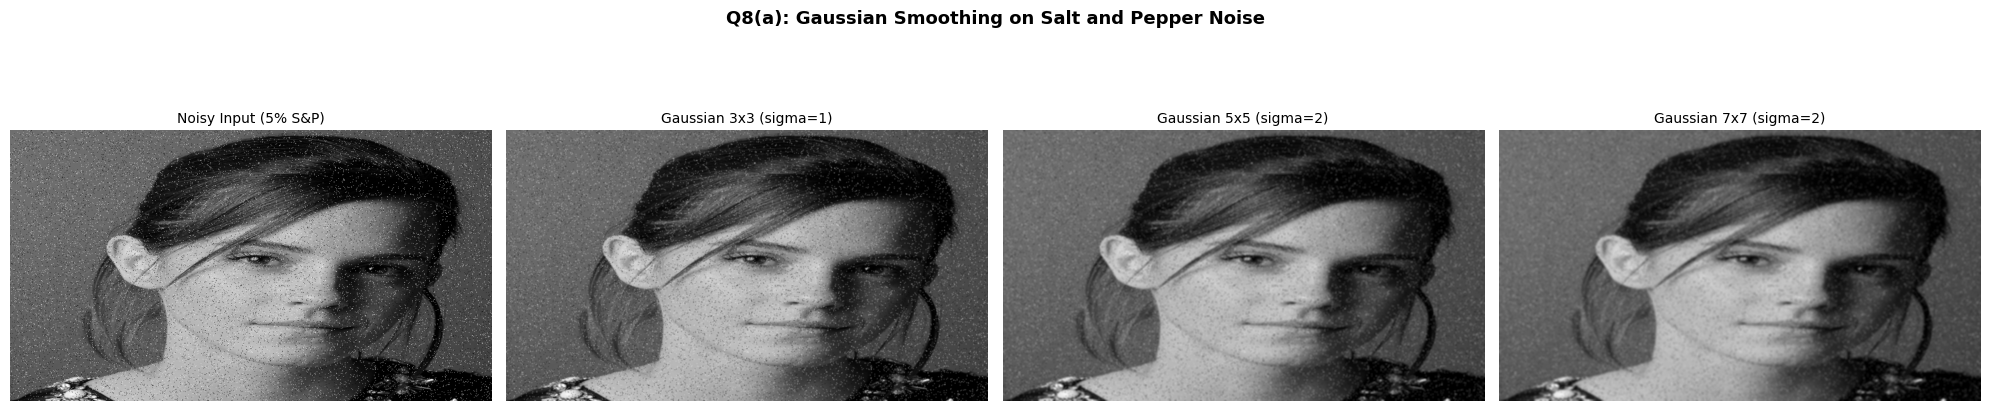

In [21]:
# Visual: noisy + 3 Gaussian results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Q8(a): Gaussian Smoothing on Salt and Pepper Noise', fontsize=13, fontweight='bold')

for ax, image, title in zip(axes,
        [img_noisy, gauss_3, gauss_5, gauss_7],
        ['Noisy Input (5% S&P)', 'Gaussian 3x3 (sigma=1)',
         'Gaussian 5x5 (sigma=2)', 'Gaussian 7x7 (sigma=2)']):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/q8/q8_gaussian_results.png', dpi=150, bbox_inches='tight')
plt.show()


## (b) Median Filtering

In [22]:
# Apply median filtering with different kernel sizes
median_3 = cv.medianBlur(img_noisy, 3)
median_5 = cv.medianBlur(img_noisy, 5)
median_7 = cv.medianBlur(img_noisy, 7)

print("Median filtering results (vs noisy):")
for name, filtered in [('Median 3', median_3), ('Median 5', median_5), ('Median 7', median_7)]:
    remaining_sp = np.sum(filtered == 0) + np.sum(filtered == 255)
    print(f"  {name} — Mean: {filtered.mean():.2f} | Std: {filtered.std():.2f} "
          f"| Remaining extreme pixels: {remaining_sp:,}")


Median filtering results (vs noisy):
  Median 3 — Mean: 92.19 | Std: 55.72 | Remaining extreme pixels: 10,586
  Median 5 — Mean: 92.14 | Std: 55.64 | Remaining extreme pixels: 9,949
  Median 7 — Mean: 92.14 | Std: 55.57 | Remaining extreme pixels: 9,604


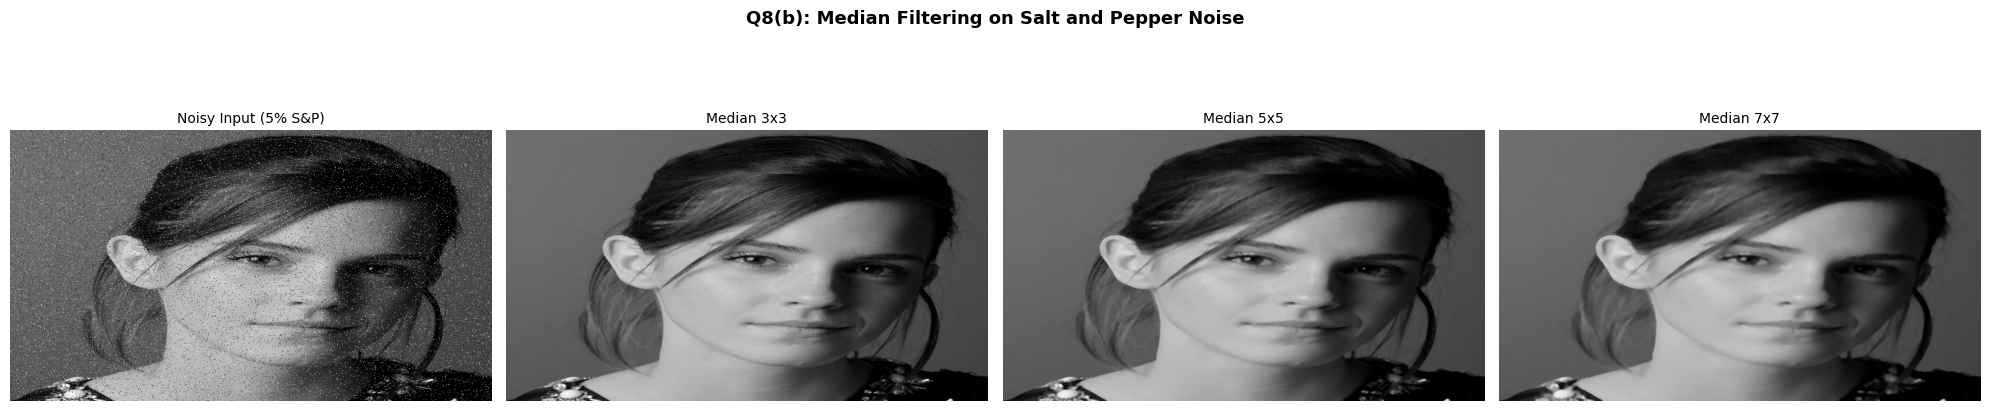

In [23]:
# Visual: noisy + 3 median results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Q8(b): Median Filtering on Salt and Pepper Noise', fontsize=13, fontweight='bold')

for ax, image, title in zip(axes,
        [img_noisy, median_3, median_5, median_7],
        ['Noisy Input (5% S&P)', 'Median 3x3', 'Median 5x5', 'Median 7x7']):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/q8/q8_median_results.png', dpi=150, bbox_inches='tight')
plt.show()


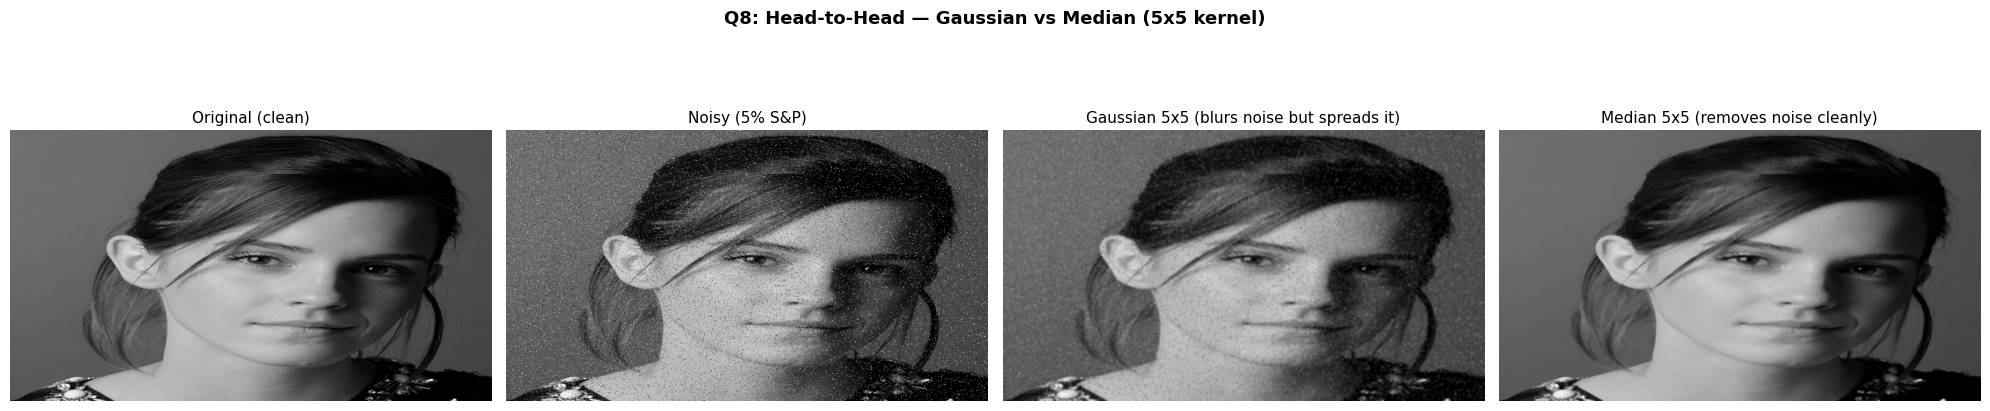

In [24]:
# Head-to-head: Gaussian 5x5 vs Median 5x5 vs original
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Q8: Head-to-Head — Gaussian vs Median (5x5 kernel)',
             fontsize=13, fontweight='bold')

axes[0].imshow(img,       cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original (clean)', fontsize=11); axes[0].axis('off')

axes[1].imshow(img_noisy, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Noisy (5% S&P)', fontsize=11); axes[1].axis('off')

axes[2].imshow(gauss_5,   cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Gaussian 5x5 (blurs noise but spreads it)', fontsize=11)
axes[2].axis('off')

axes[3].imshow(median_5,  cmap='gray', vmin=0, vmax=255)
axes[3].set_title('Median 5x5 (removes noise cleanly)', fontsize=11)
axes[3].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q8/q8_head_to_head.png', dpi=150, bbox_inches='tight')
plt.show()


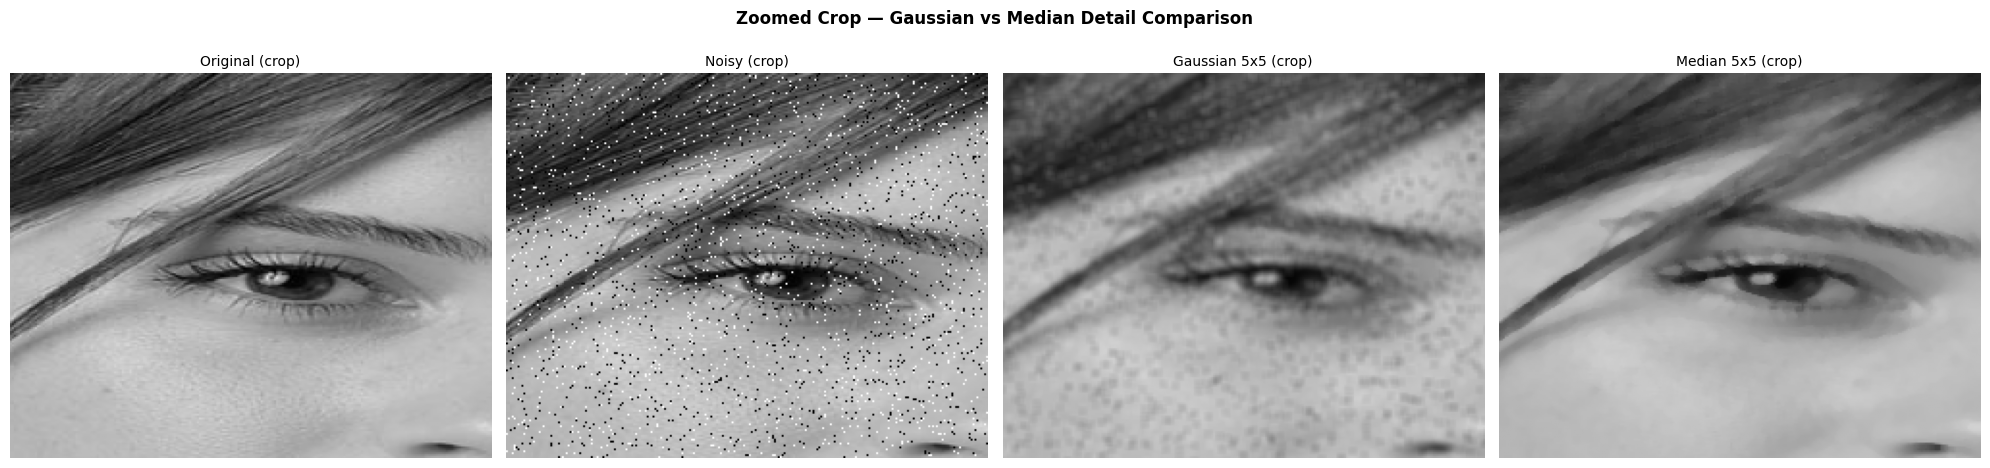

In [25]:
# Zoomed crop to show the difference clearly
crop = np.s_[150:350, 350:600]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Zoomed Crop — Gaussian vs Median Detail Comparison',
             fontsize=12, fontweight='bold')

for ax, image, title in zip(axes,
        [img[crop], img_noisy[crop], gauss_5[crop], median_5[crop]],
        ['Original (crop)', 'Noisy (crop)',
         'Gaussian 5x5 (crop)', 'Median 5x5 (crop)']):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/q8/q8_crop_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


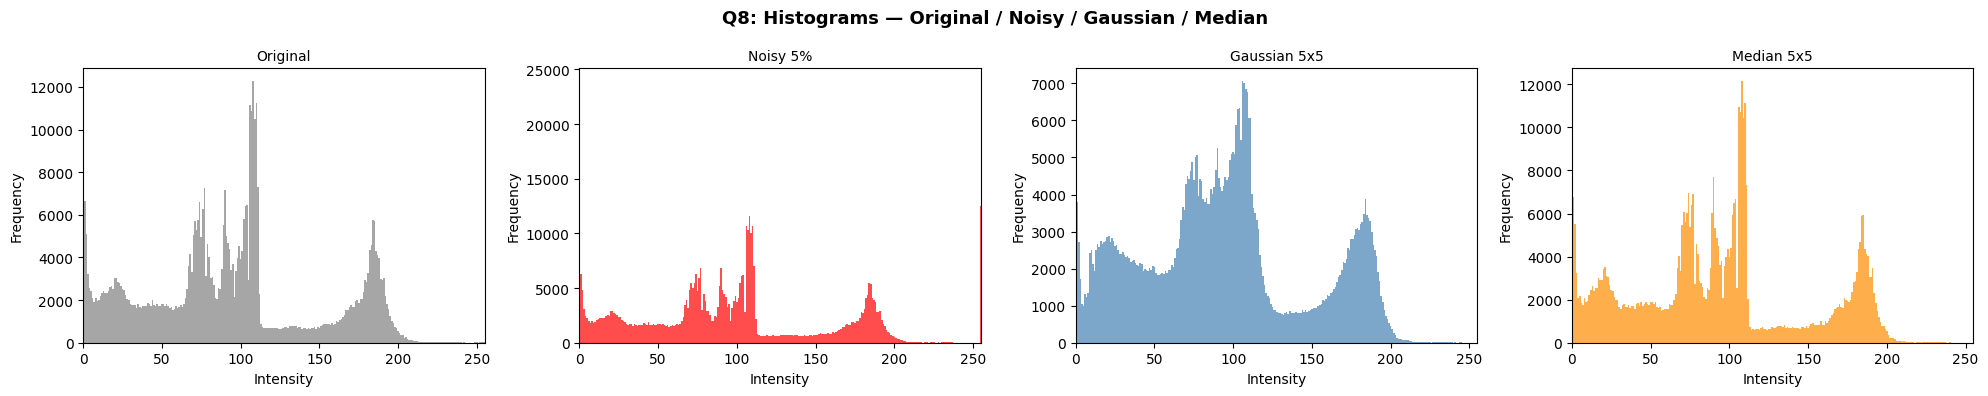

In [26]:
# Histograms: original vs noisy vs gaussian vs median
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Q8: Histograms — Original / Noisy / Gaussian / Median',
             fontsize=13, fontweight='bold')

images = [img,       img_noisy,  gauss_5,       median_5]
titles = ['Original','Noisy 5%', 'Gaussian 5x5','Median 5x5']
colors = ['gray',    'red',      'steelblue',    'darkorange']

for ax, image, title, color in zip(axes, images, titles, colors):
    hist = np.histogram(image.ravel(), bins=256, range=(0,256))[0]
    ax.bar(range(256), hist, color=color, alpha=0.7, width=1.0)
    ax.set_title(title, fontsize=10)
    ax.set_xlim([0, 255])
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/q8/q8_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# Quantitative comparison — MSE against original clean image
def mse(imgA, imgB):
    return np.mean((imgA.astype(np.float64) - imgB.astype(np.float64))**2)

def psnr(imgA, imgB):
    mse_val = mse(imgA, imgB)
    if mse_val == 0:
        return float('inf')
    return 10 * np.log10(255**2 / mse_val)

print('{:<22} {:>10} {:>10} {:>18}'.format(
    'Filter', 'MSE', 'PSNR (dB)', 'Extreme pixels'))
print('-' * 65)

for name, filtered in [
    ('Noisy (no filter)',  img_noisy),
    ('Gaussian 3x3',      gauss_3),
    ('Gaussian 5x5',      gauss_5),
    ('Gaussian 7x7',      gauss_7),
    ('Median 3x3',        median_3),
    ('Median 5x5',        median_5),
    ('Median 7x7',        median_7),
]:
    ep = np.sum(filtered == 0) + np.sum(filtered == 255)
    print('{:<22} {:>10.2f} {:>10.2f} {:>18,}'.format(
        name, mse(img, filtered), psnr(img, filtered), ep))


Filter                        MSE  PSNR (dB)     Extreme pixels
-----------------------------------------------------------------
Noisy (no filter)         1003.88      18.11             36,402
Gaussian 3x3               153.97      26.26              7,588
Gaussian 5x5                94.28      28.39              4,381
Gaussian 7x7                86.99      28.74              2,232
Median 3x3                  19.94      35.13             10,586
Median 5x5                  39.25      32.19              9,949
Median 7x7                  54.63      30.76              9,604
